In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# sklearn imports
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# -----------------------------
# Load Dataset (Boston removed, so use OpenML version)
# -----------------------------
boston = fetch_openml(name="boston", version=1, as_frame=True)
data = boston.frame

In [4]:
# Rename target column
data.rename(columns={"MEDV": "PRICE"}, inplace=True)

In [5]:
# -----------------------------
# Basic EDA
# -----------------------------
print(data.head())
print(data.shape)
print(data.isnull().sum())
print(data.describe())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  
(506, 14)
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64
             CRIM          ZN       INDUS         NOX          RM         AGE  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000

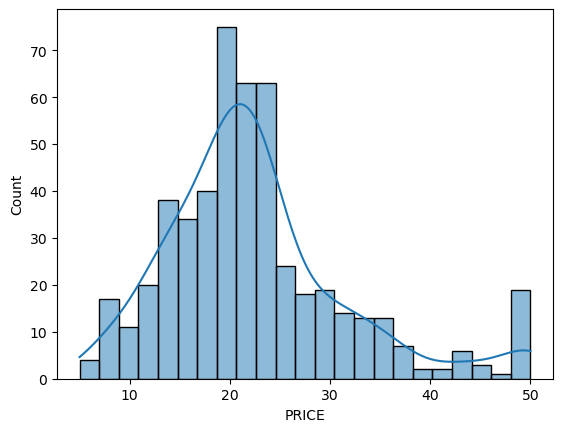

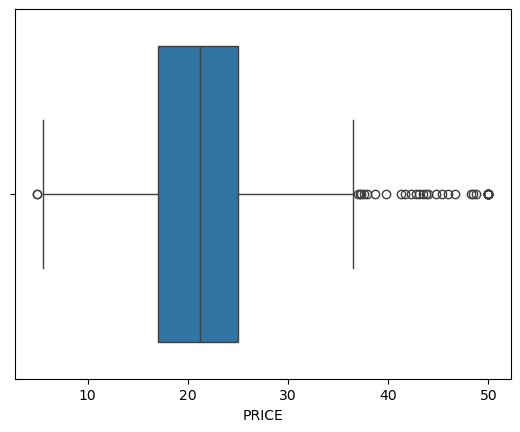

In [6]:
# -----------------------------
# Visualization
# -----------------------------
sns.histplot(data["PRICE"], kde=True)
plt.show()

sns.boxplot(x=data["PRICE"])
plt.show()

PRICE      1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: PRICE, dtype: float64


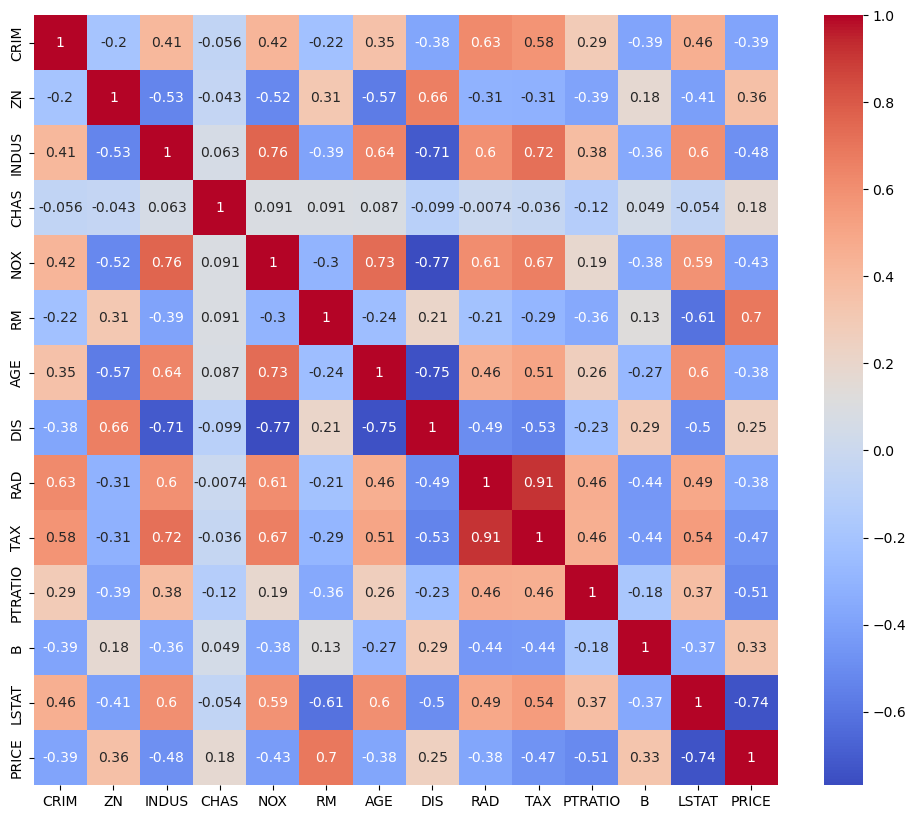

In [7]:
# -----------------------------
# Correlation
# -----------------------------
correlation = data.corr()
print(correlation["PRICE"].sort_values(ascending=False))

plt.figure(figsize=(12,10))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

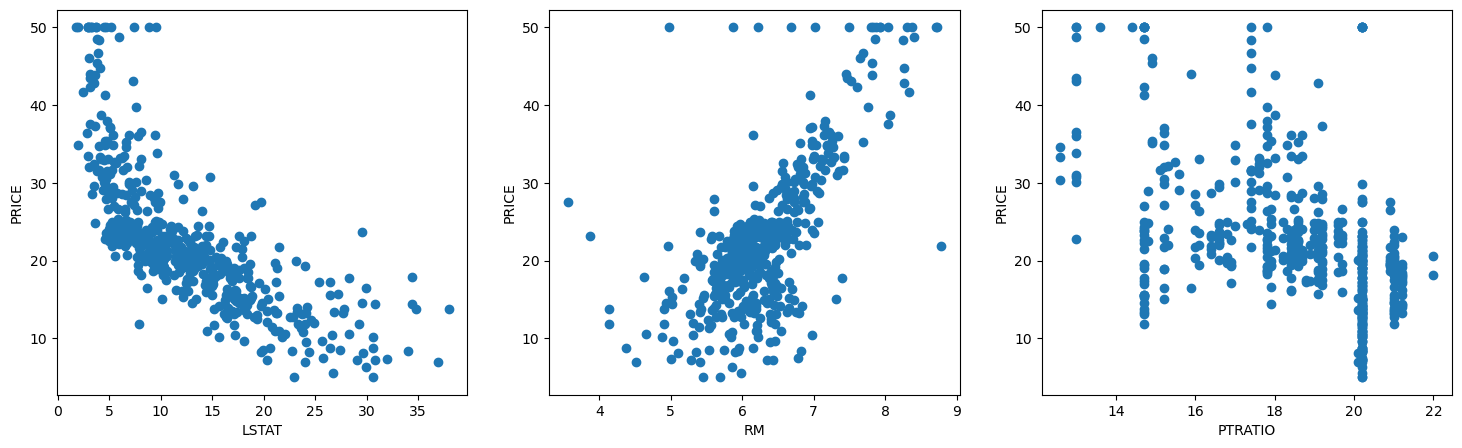

In [8]:
# -----------------------------
# Scatter plots
# -----------------------------
features = ['LSTAT', 'RM', 'PTRATIO']

plt.figure(figsize=(18,5))
for i, col in enumerate(features):
    plt.subplot(1, len(features), i+1)
    plt.scatter(data[col], data["PRICE"])
    plt.xlabel(col)
    plt.ylabel("PRICE")
plt.show()

In [9]:
# -----------------------------
# Split Data
# -----------------------------
X = data.drop("PRICE", axis=1)
y = data["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# -----------------------------
# Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# -----------------------------
# Linear Regression
# -----------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
# Metrics
print("\n--- Linear Regression ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


--- Linear Regression ---
RMSE: 4.928602182665336
MAE: 3.1890919658878483
R2: 0.6687594935356321


In [13]:
# -----------------------------
# Neural Network (Keras)
# -----------------------------
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.1,
    verbose=0
)

C:\Users\Shree\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


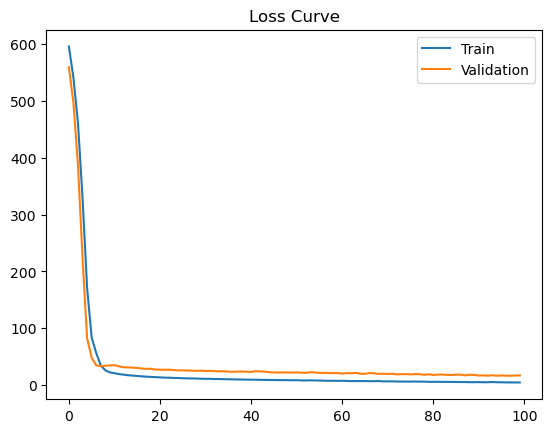

In [14]:
# -----------------------------
# Plot Loss
# -----------------------------
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [15]:
# -----------------------------
# Evaluate NN
# -----------------------------
y_pred_nn = model.predict(X_test)

print("\n--- Neural Network ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("MAE:", mean_absolute_error(y_test, y_pred_nn))
print("R2:", r2_score(y_test, y_pred_nn))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

--- Neural Network ---
RMSE: 3.274159477682003
MAE: 2.1933373829897715
R2: 0.8538174382486382


In [16]:
# -----------------------------
# Prediction on New Data
# -----------------------------
new_data = np.array([[0.1, 10.0, 5.0, 0, 0.4, 6.0, 50, 6.0, 1, 400, 20, 300, 10]])
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)
print("\nPredicted House Price:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

Predicted House Price: [[13.805663]]


C:\Users\Shree\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
